# Logistic Regression — Gradient Descent Formulation

## 1. Problem Setup

Assume we have a dataset

$$
\{(x_i,y_i)\}_{i=1}^{N}
$$

where

$$
x_i \in \mathbb{R}^D
$$

is the feature vector and

$$
y_i \in \{0,1\}
$$

is the binary class label.

Logistic regression models the probability that an observation belongs to class 1.

---

## 2. Linear Model

The model first computes a linear combination of the input features

$$
z_i = w^T x_i
$$

where

$$
w \in \mathbb{R}^D
$$

is the weight vector.

---

## 3. Adding the Bias Term

To include an intercept term, the feature vector is augmented with a constant value

$$
x_i =
\begin{bmatrix}
1 \\
x_i
\end{bmatrix}
$$

The weight vector becomes

$$
w =
\begin{bmatrix}
b \\
w
\end{bmatrix}
$$

Thus the linear model becomes

$$
z_i = w^T x_i
$$

where the first component corresponds to the bias.

---

## 4. Sigmoid Function

The linear output is transformed into a probability using the sigmoid function

$$
\sigma(z)=\frac{1}{1+e^{-z}}
$$

Thus the predicted probability becomes

$$
p_i = P(y_i=1|x_i)
$$

$$
p_i = \sigma(w^T x_i)
$$

which ensures

$$
0 \le p_i \le 1
$$

---

## 5. Objective Function (Binary Cross-Entropy)

Logistic regression minimizes the **negative log-likelihood**.

For one observation

$$
L_i =
-
\left[
y_i\log(p_i) +
(1-y_i)\log(1-p_i)
\right]
$$

For the full dataset

$$
L(w)
=
-
\sum_{i=1}^{N}
\left[
y_i\log(p_i) +
(1-y_i)\log(1-p_i)
\right]
$$

where

$$
p_i = \sigma(w^T x_i)
$$

---

## 6. Matrix Representation

Define the design matrix

$$
X =
\begin{bmatrix}
x_1^T \\
x_2^T \\
\vdots \\
x_N^T
\end{bmatrix}
$$

and the target vector

$$
y =
\begin{bmatrix}
y_1 \\
y_2 \\
\vdots \\
y_N
\end{bmatrix}
$$

The vector of predicted probabilities becomes

$$
p = \sigma(Xw)
$$

---

## 7. Gradient of the Loss Function

To minimize the loss function we compute its gradient with respect to the weights.

The gradient becomes

$$
\nabla L(w)
=
X^T(p-y)
$$

where

$$
p =
\begin{bmatrix}
p_1 \\
p_2 \\
\vdots \\
p_N
\end{bmatrix}
$$

---

## 8. Hessian Matrix

The second derivative of the loss function is

$$
H =
X^T R X
$$

where

$$
R =
\text{diag}(p_i(1-p_i))
$$

is a diagonal matrix containing the variance of each Bernoulli observation.

---

## 9. Gradient Descent Update Rule

Gradient descent iteratively updates the weights using

$$
w_{t+1}
=
w_t
-
\eta \nabla L(w_t)
$$

Substituting the gradient expression gives

$$
w_{t+1}
=
w_t
-
\eta X^T(p-y)
$$

where

- $\eta$ is the learning rate  
- $t$ is the iteration index

---

## 10. Initialization

The algorithm typically starts with

$$
w = 0
$$

At this point

$$
z = Xw = 0
$$

and the predicted probabilities become

$$
p = \sigma(0) = 0.5
$$

---

## 11. Iterative Optimization

At each iteration the following steps are performed.

Compute linear predictions

$$
z = Xw
$$

Compute probabilities

$$
p = \sigma(z)
$$

Compute the gradient

$$
\nabla L = X^T(p-y)
$$

Update the weights

$$
w = w - \eta \nabla L
$$

This process continues until convergence.

---

## 12. Convergence Criterion

The algorithm stops when the gradient becomes sufficiently small

$$
\|\nabla L\| < \epsilon
$$

where

$$
\epsilon
$$

is a small tolerance value.

Alternatively, convergence may be determined using a fixed number of iterations.

---

## 13. Geometric Interpretation

Logistic regression learns a **linear decision boundary**.

The boundary is defined by

$$
w^T x = 0
$$

Points satisfying

$$
w^T x > 0
$$

are classified as class 1, while points with

$$
w^T x < 0
$$

are classified as class 0.

---

## 14. Prediction

After training, predictions are computed using

$$
p = \sigma(Xw)
$$

The final class label is determined by

$$
\hat{y} =
\begin{cases}
1 & p \ge 0.5 \\
0 & p < 0.5
\end{cases}
$$


---

## 15. Algorithm Summary

Initialize

$$
w = 0
$$

Repeat until convergence:

Compute predictions

$$
p = \sigma(Xw)
$$

Compute gradient

$$
\nabla L = X^T(p-y)
$$

Update weights

$$
w = w - \eta X^T(p-y)
$$

Check stopping condition.

---

## 16. Final Optimization Problem

The optimization problem solved by logistic regression is

$$
\min_w
-
\sum_{i=1}^{N}
\left[
y_i\log(\sigma(w^Tx_i))
+
(1-y_i)\log(1-\sigma(w^Tx_i))
\right]
$$

This produces a classifier that separates two classes using a **linear decision boundary in the feature space**.

In [1]:
class LogisticRegressionGD:
    def __init__(self,add_bias=True, num_iterations=100 , tolerance =1e-5 , learning_rate=0.001):
        self.add_bias = add_bias
        self.num_iterations = num_iterations
        self.tolerance = tolerance
        self.learning_rate = learning_rate


        self.weights = None



    def sigmoid(self,X):
        p  = np.empty_like(X,dtype=float)
        positive = X>=0
        negative = ~ positive
        p[positive] = 1 /(1+ np.exp(-X[positive]))
        p[negative] = np.exp(X[negative]) / (1+ np.exp(X[negative]))

        return p


    def fit(self,X,y):
        X = np.asarray(X)
        y = np.asarray(y)

        y = y.reshape(-1)

        if X.ndim==1:
            X = X.reshape(-1,1)

        N , D = X.shape

        if self.add_bias:
            X = np.column_stack((np.ones(N),X))
            D +=1

        self.weights = np.zeros(D)
        a = X.T
        b = a @ y
        for i in range(self.num_iterations):
            Z = X @ self.weights 
            p = self.sigmoid(Z)
            p = np.clip(p , 1e-12 , 1-1e-12)


            grad = a @ p - b

            self.weights = self.weights - self.learning_rate * grad

            if i > 0 and np.linalg.norm(grad)  < self.tolerance :        
                print(f"Converged in iteration: {i}")
                break
        print(f"Model Weights : {self.weights}")


    def predict(self,X):
        X = np.asarray(X)


        if X.ndim==1:
            X = X.reshape(-1,1)

        N = len(X)

        if self.add_bias:
            X = np.column_stack((np.ones(N),X))
        Z = X @ self.weights 
        p = self.sigmoid(Z)
        
        return np.where(p>=0.5,1,0)
        

## 1. Logistic Regression (Without Bias)

Assume the true weight vector is:

$$
\mathbf{w}_{\text{true}} = [2.0, -1.5]
$$

Data is generated using these weights and the logistic model.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

N = 10000
D = 2

X = np.random.randn(N, D)

w_true = np.array([2.0, -1.5])

z = X @ w_true

p = 1 / (1 + np.exp(-z))

y = np.random.binomial(1, p)

print("True weights:", w_true)

True weights: [ 2.  -1.5]


In [3]:
model = LogisticRegressionGD(add_bias=False, num_iterations=1000, learning_rate=0.001, tolerance=1e-5)
model.fit(X, y)

Converged in iteration: 39
Model Weights : [ 2.08576573 -1.56445268]


---
## 2. Logistic Regression (With Bias)

Assume the true parameters are:

$$
\mathbf{w}_{\text{true}} = [b_{\text{true}}, w_1, w_2]
$$

where the first element represents the bias.

In [4]:
N = 10000
D = 2

X = np.random.randn(N, D)

bias_true = 0.7
w_true = np.array([1.5, -2.0])

z = bias_true + X @ w_true

p = 1 / (1 + np.exp(-z))

y = np.random.binomial(1, p)

print("True bias:", bias_true)
print("True weights:", w_true)

True bias: 0.7
True weights: [ 1.5 -2. ]


In [5]:
model = LogisticRegressionGD(add_bias=True, num_iterations=1000, learning_rate=0.001, tolerance=1e-5)
model.fit(X, y)

Converged in iteration: 38
Model Weights : [ 0.68776653  1.45092854 -2.00375558]


---
## 3. Logistic Regression on Perfectly Separable Data

Here, we generate a **2D dataset** that is perfectly separable.  

- Class 0 is centered at (-2, -2)  
- Class 1 is centered at (+2, +2)  

We will train logistic regression **with bias**.  

**Expected behavior:**  
- Logistic regression tries to push predicted probabilities to 0 or 1.  
- Gradient descent **does not converge** to finite weights because the data is perfectly separable.  
- Weights keep increasing in magnitude over iterations.
- Despite the weights diverging, *the loss function smoothly approaches zero*, as the sigmoid function gets closer to 0 or 1

In [6]:
N = 200

X_class0 = np.random.randn(N//2, 2) - 2   
X_class1 = np.random.randn(N//2, 2) + 2  

X = np.vstack((X_class0, X_class1))
y = np.array([0]*(N//2) + [1]*(N//2))

w_true = np.array([1.0, 1.0])
print("True weights:", w_true)

True weights: [1. 1.]


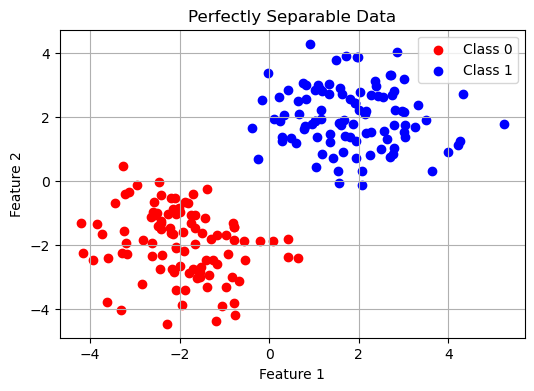

In [7]:
plt.figure(figsize=(6,4))
plt.scatter(X_class0[:,0], X_class0[:,1], color='red', label='Class 0')
plt.scatter(X_class1[:,0], X_class1[:,1], color='blue', label='Class 1')
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Perfectly Separable Data")
plt.legend()
plt.grid(True)
plt.show()

### Training Logistic Regression

We now train logistic regression on the perfectly separable data.

- Because the data is perfectly separable, **gradient descent does not converge** to finite weights.  
- The weights will keep increasing to push probabilities toward 0 or 1.  
- This demonstrates the limitation of logistic regression on perfectly separable data.

In [8]:
iteration_list = [10, 50, 100, 200, 500, 1000, 5000, 10000, 15000, 20000, 100000]

for iters in iteration_list:
    print(f"\nTraining model with {iters} iterations")
    model = LogisticRegressionGD(add_bias=False, num_iterations=iters, learning_rate=0.0001, tolerance=1e-5)
    model.fit(X, y)


Training model with 10 iterations
Model Weights : [0.15809561 0.16482482]

Training model with 50 iterations
Model Weights : [0.46378644 0.48675574]

Training model with 100 iterations
Model Weights : [0.64088494 0.67693036]

Training model with 200 iterations
Model Weights : [0.83337613 0.88892183]

Training model with 500 iterations
Model Weights : [1.10539032 1.20205485]

Training model with 1000 iterations
Model Weights : [1.32266139 1.46683253]

Training model with 5000 iterations
Model Weights : [1.86226973 2.19588433]

Training model with 10000 iterations
Model Weights : [2.10827138 2.57111982]

Training model with 15000 iterations
Model Weights : [2.25518534 2.81248179]

Training model with 20000 iterations
Model Weights : [2.36048736 2.99520811]

Training model with 100000 iterations
Model Weights : [2.96058765 4.2541212 ]
